In [1]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymatgen.core import Structure
from cdft.dft3d_pcsaft import dft_core
from cdft.pcsaft_eos import pcsaft

torch.set_default_dtype(torch.float64)
device = torch.device('cuda')

In [2]:
m = torch.tensor([1.0, 1.6069])
sigma = torch.tensor([3.7039, 3.5206])
epsilon = torch.tensor([150.03, 191.42])
parameters = {'m':m, 'sigma':sigma, 'epsilon':epsilon}

In [3]:
structure = Structure.from_file('structures/IRMOF-1.cif')
print('formula:        ', structure.formula)
print('num_sites:      ', structure.num_sites)
print('lattice_lengths:', structure.lattice.lengths)

formula:         Zn32 H96 C192 O104
num_sites:       424
lattice_lengths: (25.832, 25.832, 25.832)


/home/lucas/miniforge3/envs/cdft/lib/python3.14/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: Skipping relative stoichiometry check because CIF does not contain formula keys.
  return parser.parse_structures(primitive=primitive)[0]


In [4]:
T = 300.0
system_size = np.array([l for l in structure.lattice.lengths])
points = np.array([64, 64, 64])
dft = dft_core(parameters, T, system_size, points, device)

In [5]:
forcefield = pd.DataFrame()
forcefield['type'] = ['Zn','H','C','O']
forcefield['sigma'] = np.array([4.045, 2.846, 3.47299, 3.033])
forcefield['epsilon'] = np.array([27.677, 7.6489, 47.8562, 48.1581])
forcefield['mass'] = np.array([65.38, 1.00784, 12.0107, 15.999])

def lj_potential(r,sigma,epsilon):
    return 4.0*epsilon*((sigma/r)**12-(sigma/r)**6) 

Vext = torch.zeros((dft.Nc, points[0], points[1], points[2]),device=device)
U = torch.zeros_like(dft.X)
rc = 12.0
for i in range(dft.Nc):
    for k, site in enumerate(structure):
        sigmas = float(forcefield['sigma'][forcefield['type']==site.species_string].values[0])
        epsilons = float(forcefield['epsilon'][forcefield['type']==site.species_string].values[0])
        sigmasf = 0.5*(sigma[i].numpy()+sigmas) 
        epsilonsf = np.sqrt(epsilon[i].numpy()*epsilons)
        rx = dft.X-structure.cart_coords[k,0] 
        ry = dft.Y-structure.cart_coords[k,1] 
        rz = dft.Z-structure.cart_coords[k,2] 
        rx -= system_size[0]*(rx/system_size[0]).round()
        ry -= system_size[1]*(ry/system_size[1]).round()
        rz -= system_size[2]*(rz/system_size[2]).round()
        r = torch.sqrt(rx**2+ry**2+rz**2)
        U = m[i]*lj_potential(r,sigmasf,epsilonsf)
        U[r==0] = np.inf
        U[r>rc] = 0.0
        Vext[i] += U

Text(0, 0.5, '$y$ (\\AA{})')

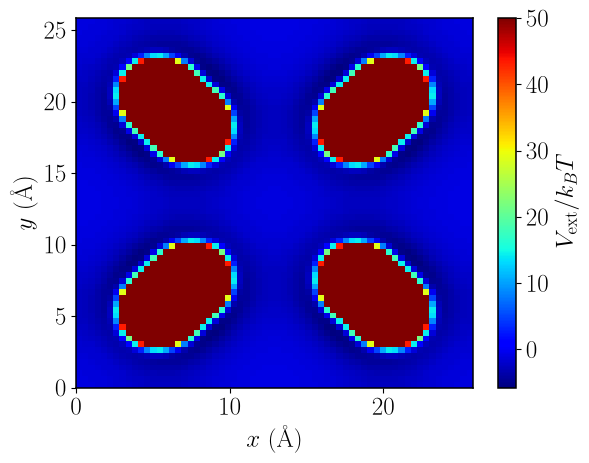

In [6]:
plt.rcParams.update({'text.usetex':True, 
'font.family':'serif', 
'font.size':18, 
'axes.linewidth':1.1, 
'lines.linewidth':1.6,
'legend.fontsize': 18,
'legend.frameon':False
#'figure.figsize':(7.9, 6.1)
})


plt.figure()
c=plt.pcolormesh(dft.X[:,:,points[0]//2].cpu(),dft.Y[:,:,points[1]//2].cpu(),Vext[1,:,:,points[2]//2].cpu()/T, vmax=50.0, cmap='jet')
plt.colorbar(label=r'$V_{\mathrm{ext}}/k_B T$')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')

In [7]:
P = torch.hstack((torch.arange(1e5,1e6,1e5), torch.range(1e6,1e7,1e6)))

bulk_density = torch.empty_like(P)
composition = torch.tensor([0.4,0.6])

eos = pcsaft(parameters, T)
bulk_density[0] = eos.density(P[0],composition,'vap')
for i in range(1,len(P)):
    bulk_density[i] = eos.density(P[i],composition,bulk_density[i-1])

/tmp/ipykernel_28553/3125288185.py:1: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  P = torch.hstack((torch.arange(1e5,1e6,1e5), torch.range(1e6,1e7,1e6)))


In [8]:
dft.initial_condition(bulk_density[0],composition,Vext)

In [9]:
Nads = torch.empty((dft.Nc,len(P)))
for i in range(len(P)):
    dft.equilibrium_density_profile(bulk_density[i],composition,fmt='ASWB',solver='anderson',
                                    anderson_mmax=10,anderson_damping=0.2,tol=1e-6,logoutput=False)
    for j in range(dft.Nc):
        Nads[j,i] = dft.total_molecules[j]
    print(dft.it,dft.error.numpy(),1e-5*P[i].numpy(),Nads[:,i].numpy())
    if np.isnan(dft.error.numpy()): break

14 7.292641732339738e-07 1.0 [1.19297789 9.25350475]
14 3.5118200052298954e-07 2.0 [ 2.56741032 23.15931989]
15 1.308919015021959e-07 3.0000000000000004 [ 3.83186584 38.47188805]
15 1.9596515768732836e-07 4.0 [ 4.80119121 51.31786407]
14 2.48811905505808e-07 5.0 [ 5.50230777 60.60213096]
14 5.634767141697301e-07 6.000000000000001 [ 6.0363037  67.21157213]
14 7.391888849035583e-07 7.000000000000001 [ 6.47099351 72.09384377]
14 9.651581661689038e-07 8.0 [ 6.84281123 75.8482124 ]
15 6.977275309555414e-07 9.0 [ 7.17190457 78.83437326]
16 5.761114375313013e-07 10.0 [ 7.47021833 81.27452119]
22 8.299403741718e-07 20.0 [ 9.69609477 93.11959704]
23 9.653418236333292e-07 30.000000000000004 [11.43634837 97.38837848]
23 9.271396662785854e-07 40.0 [13.08108378 99.2830608 ]
24 5.818058038822702e-07 50.00000000000001 [14.78974514 99.94686329]
23 6.247184779526228e-07 60.00000000000001 [16.68837652 99.75465066]
23 9.531091139627329e-07 70.0 [18.88541948 98.85351103]
23 9.307353105946352e-07 80.0 [21.

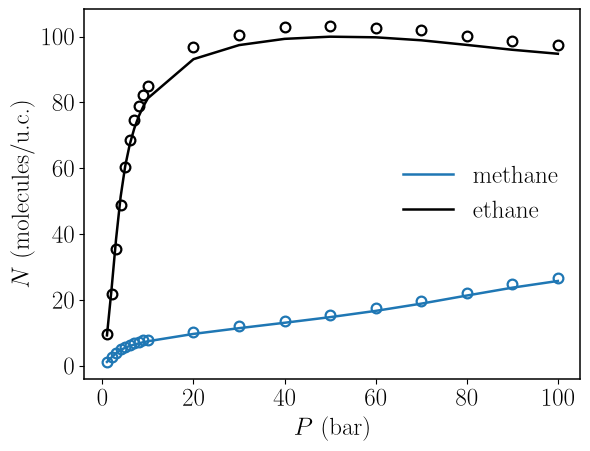

In [10]:
data = pd.read_pickle('data/isotherm_methane_ethane.pkl')

plt.plot(P*1e-5, Nads[0], 'C0-', linewidth=1.8, label='methane')
plt.plot(P*1e-5, Nads[1], 'k-', linewidth=1.8, label='ethane')
plt.plot(data['pressure'], data['methane'], 'C0o', markersize=7, markeredgewidth=1.6, mfc = 'none')
plt.plot(data['pressure'], data['ethane'], 'ko', markersize=7, markeredgewidth=1.6, mfc = 'none')
plt.xlabel(r'$P$ (bar)')
plt.ylabel(r'$N$ (molecules/u.c.)')
plt.legend()